In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
data = pd.read_csv("clean_dataset.csv")

data_clean = data.dropna()

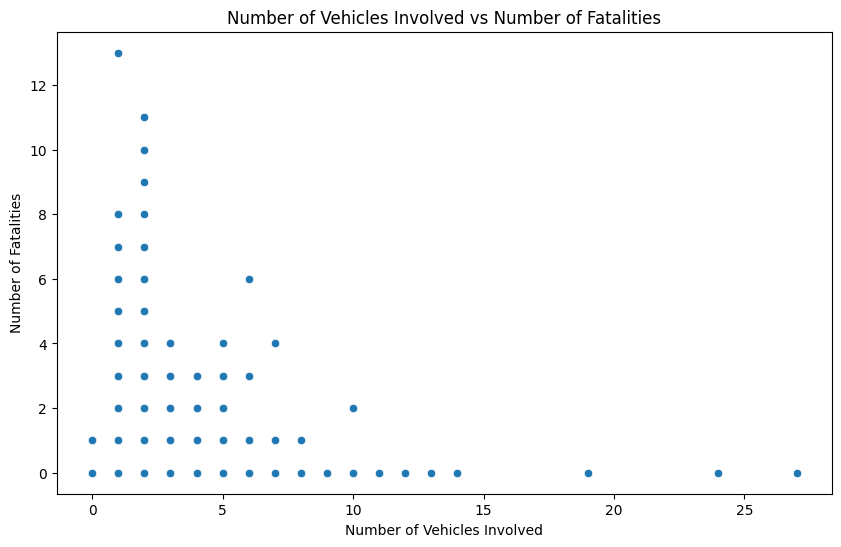

In [10]:
#Distribution plot of the data


plt.figure(figsize=(10,6))
sns.scatterplot(x='number_of_vehicles_involved',y='number_of_fatalities',data=data_clean)
plt.title('Number of Vehicles Involved vs Number of Fatalities')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Fatalities')
plt.show()

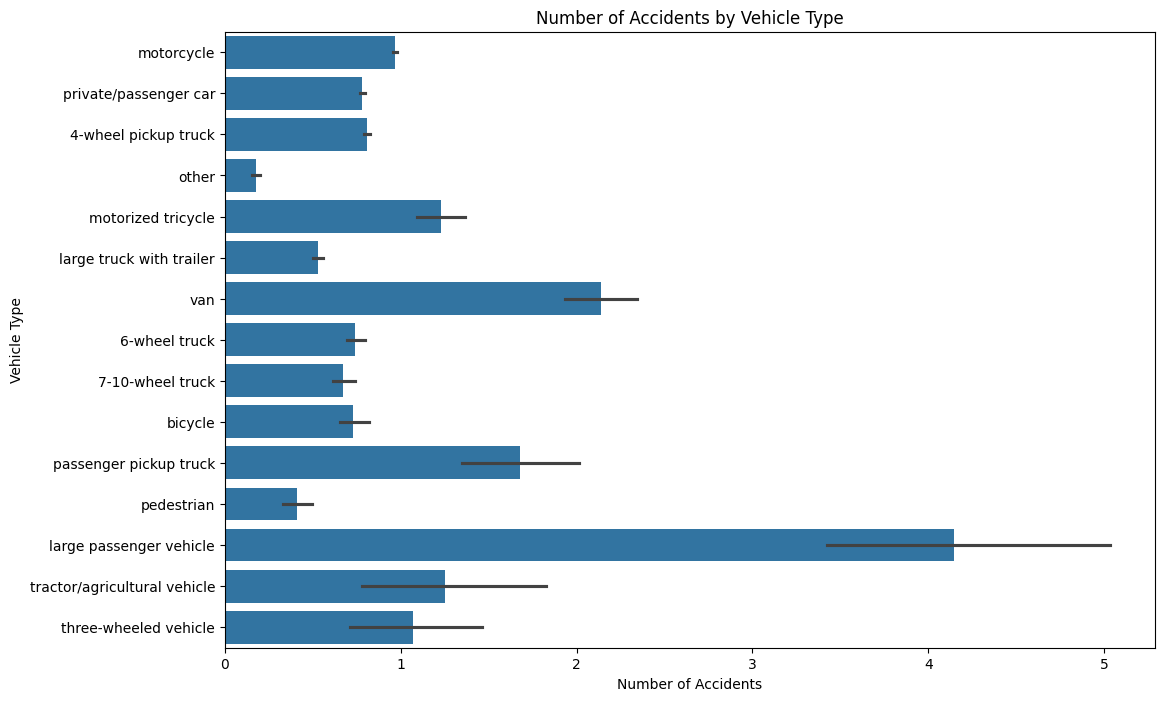

In [11]:
#Bar chart of accidents by vehicle type
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.barplot(x='number_of_injuries',y='vehicle_type',data=data_clean)
plt.title('Number of Accidents by Vehicle Type')
plt.xlabel('Number of Accidents')
plt.ylabel('Vehicle Type')
plt.show()

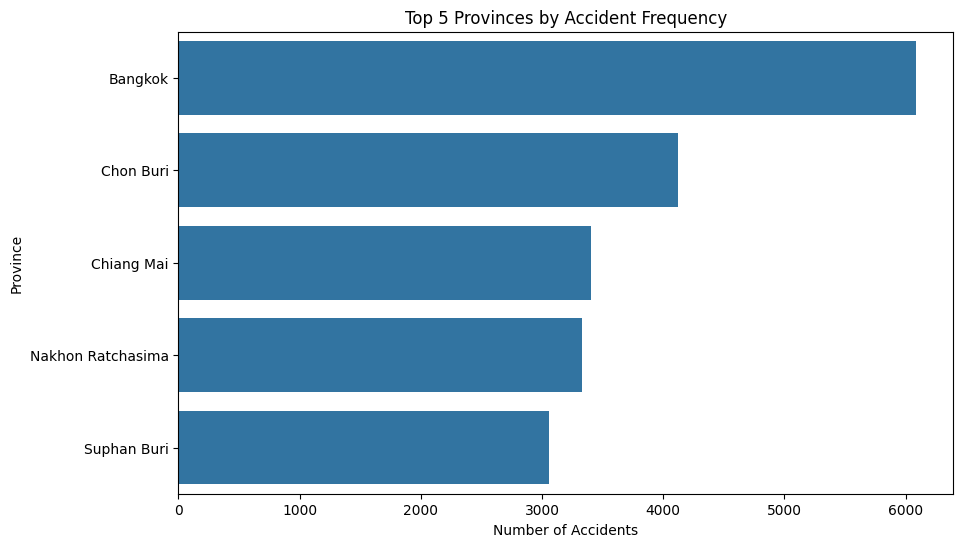

In [ ]:
#Ranking: Top 5 provinces with by accident count
plt.figure(figsize=(10,6))

province_rank = data_clean['Province'].value_counts().head(5)
sns.barplot(x=province_rank.values, y=province_rank.index)

plt.title('Top 5 Provinces by Accident Frequency')
plt.xlabel('Number of Accidents')
plt.ylabel('Province')
plt.show()

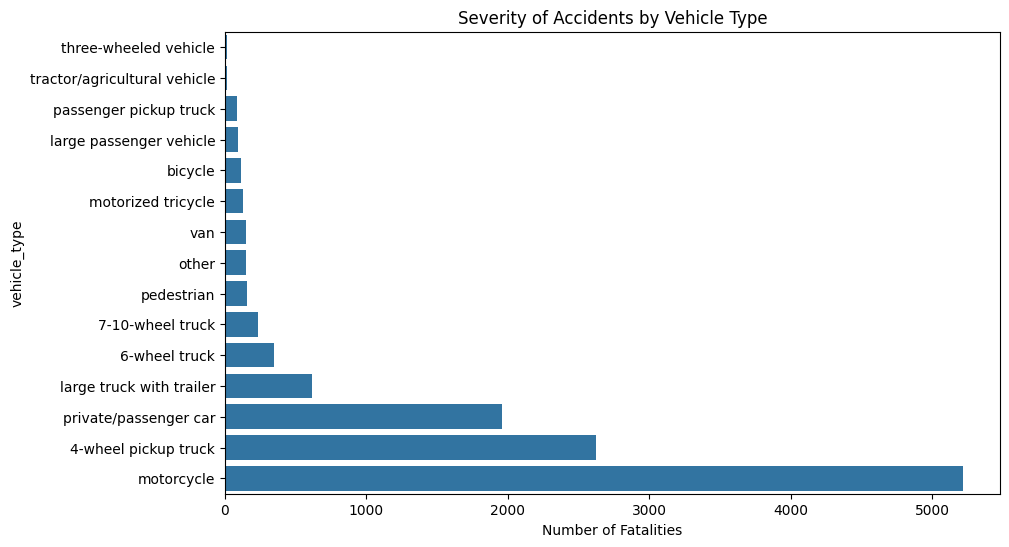

In [20]:
#Segmentation: Severity of accidents by vehicle type
accident_severity= data_clean.groupby('vehicle_type')['number_of_fatalities'].sum().sort_values(ascending=True)
plt.figure(figsize=(10,6))
sns.barplot(x=accident_severity.values, y=accident_severity.index)
plt.title('Severity of Accidents by Vehicle Type')
plt.xlabel('Number of Fatalities')
plt.show()

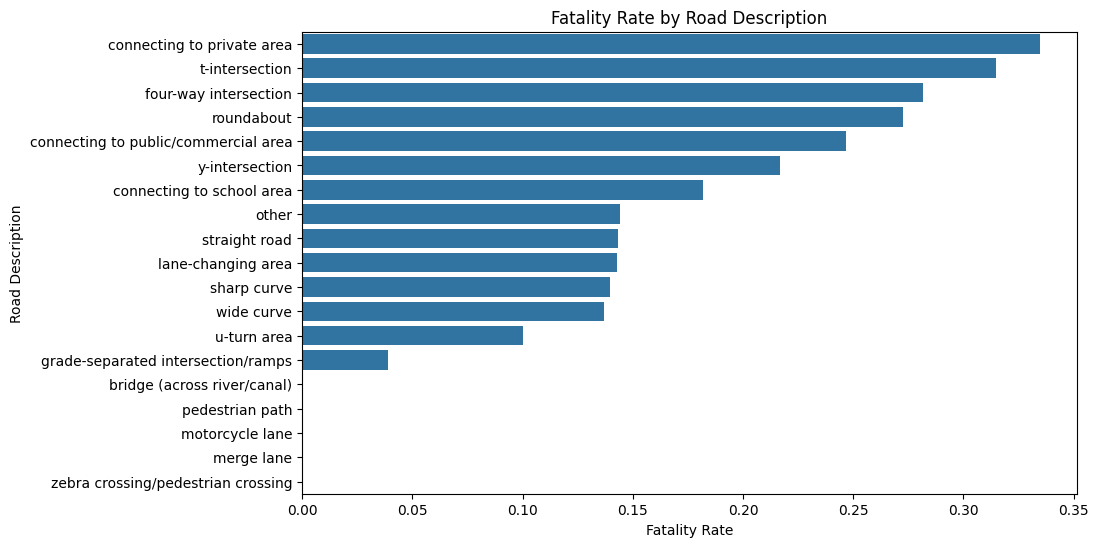

In [21]:
#Comparison
#Fatality Rate by Road Description 
road_comparison = data_clean.groupby('road_description')['number_of_fatalities'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=road_comparison.values, y=road_comparison.index)
plt.title('Fatality Rate by Road Description')
plt.xlabel('Fatality Rate')
plt.ylabel('Road Description')
plt.show()

In [28]:
import folium
from folium.plugins import HeatMap  

heat_df=data_clean[['latitude','longitude']].dropna()

heat_data=heat_df.values.tolist()

map_center=[heat_df['latitude'].mean(), heat_df['longitude'].mean()]
accident_map= folium.Map(location=map_center, zoom_start=6, tiles='OpenStreetMap')
HeatMap( heat_data, radius=10, blur=15, min_opacity=0.5).add_to(accident_map)
accident_map 